# Objectif : Calculer la probabiliter de défaut

In [ ]:
import numpy as np
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns

sys.path.append(os.path.abspath(".."))
from src.discretization import (plot_bad_rate_by_quantile,prepare_chimerge,apply_chimerge,apply_binning,
                                check_binning_quality,compute_woe_iv,
                                chimerge_categorical)

ImportError: cannot import name 'prepare_chimerge_auto' from 'src.discretization' (c:\Mosef\scoring\projet\src\discretization.py)

In [ ]:
df_credit = pd.read_csv("../data/output/df_credit_clear.csv",sep = ",")

### Discretisation

In [ ]:
df_credit.columns

Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
df_credit_discretisation = df_credit.copy()

# ChiMerge — Méthode de discrétisation supervisée

## Définition

**ChiMerge (Chi-square Merge)** est une méthode de discrétisation supervisée
qui consiste à fusionner automatiquement des classes voisines
si elles n’ont pas de différence significative dans la variable cible (ex. le taux de défaut).

Autrement dit :
on regroupe les intervalles d’une variable tant qu’ils présentent le même risque de défaut,
selon un **test statistique du Chi²**.

---

## Objectif

### Objectif principal
Transformer une variable continue (âge, revenu, ratio prêt/revenu, etc.)
en **quelques classes homogènes en risque**, c’est-à-dire où les clients d’une même classe
ont le même comportement de défaut.

### Objectif pratique
- Supprimer le bruit (petites différences dues au hasard)
- Créer des bins statistiquement distincts
- Obtenir une relation monotone et stable avec la probabilité de défaut
- Préparer la variable pour le calcul du **WOE / IV** ou une **régression logistique**

---

## Fonctionnement

### Étape 1 — Découpage initial
Découper la variable en plusieurs petits intervalles (souvent 10 ou 20 déciles).

Exemple : `loan_percent_income`
→ (0–0.05], (0.05–0.10], (0.10–0.15], …

---

### Étape 2 — Calcul des effectifs par bin
Pour chaque intervalle, on compte :
- le nombre de **bons clients** (`loan_status = 0`)
- le nombre de **mauvais clients** (`loan_status = 1`)

---

### Étape 3 — Test du Chi² entre bins voisins
On teste l’hypothèse :
> “Ces deux bins ont le même taux de défaut.”

Le test du **χ² (Chi-square)** compare la répartition bons/mauvais entre deux classes adjacentes.

- Si la différence **n’est pas significative (p > 0.05)** → on les **fusionne**
- Si elle **est significative (p < 0.05)** → on les garde séparées

**On veut que chaque bin regroupe des individus “statistiquement similaires” et que les bins entre eux soient “statistiquement différents” en termes de risque.**

---

### Étape 4 — Répétition
On répète la fusion jusqu’à :
- atteindre un **seuil de significativité minimal**
- ou un **nombre cible de classes finales** (souvent 4 à 6)

---

### Étape 5 — Résultat
| Bin final | Intervalle | Taux de défaut | Interprétation |
|------------|-------------|----------------|----------------|
| 1 | (0–0.10] | 0.04 | Faible risque |
| 2 | (0.10–0.20] | 0.08 | Risque modéré |
| 3 | (0.20–0.40] | 0.20 | Risque élevé |
| 4 | (0.40–1.00] | 0.45 | Risque très élevé |

---

## Pourquoi c’est important

| Raison | Explication |
|--------|--------------|
| Stabilité | Moins sensible aux valeurs extrêmes ou au bruit |
| Interprétabilité | Chaque classe a un sens métier (“revenu faible”, “revenu moyen”, etc.) |
| Monotonicité | Le risque évolue dans un seul sens |
| Préparation au WOE | Les classes sont homogènes et distinctes en risque |

---

## Résumé

| Étape | Ce qu’on fait | Pourquoi |
|--------|----------------|-----------|
| 1️⃣ | Découper en petites classes (déciles) | Explorer le risque |
| 2️⃣ | Calculer bons/mauvais | Préparer le test |
| 3️⃣ | Appliquer le χ² sur classes voisines | Fusionner les bins similaires |
| 4️⃣ | Répéter jusqu’à seuil ou 5 classes | Obtenir des classes stables |
| 5️⃣ | Vérifier monotonicité / WOE | Finaliser la variable pour le modèle |

---

### En résumé

**ChiMerge** permet de simplifier une variable continue
en quelques classes stables et statistiquement distinctes
selon leur risque de défaut.  
C’est une étape clé dans la construction de modèles de scoring de crédit.


**Variable age :**

c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]


,person_age_bin,bad_rate
0,"(19.999, 22.0]",0.258841
1,"(22.0, 23.0]",0.218142
2,"(23.0, 24.0]",0.219824
3,"(24.0, 25.0]",0.228964
4,"(25.0, 26.0]",0.215582
5,"(26.0, 27.0]",0.212538
6,"(27.0, 29.0]",0.218279
7,"(29.0, 31.0]",0.206547
8,"(31.0, 36.0]",0.209948
9,"(36.0, 70.0]",0.213339


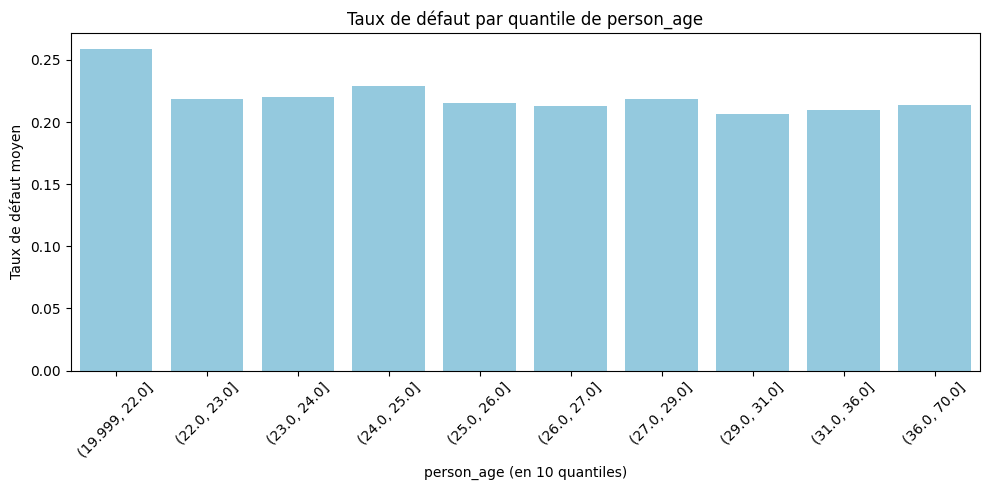

In [ ]:
plot_bad_rate_by_quantile(df = df_credit_discretisation,
                          var = "person_age",
                          q = 10)

In [ ]:
counts = prepare_chimerge(df_credit_discretisation, "person_age", q=10)
intervals = apply_chimerge(counts, max_bins=5)
intervals


c:\Mosef\scoring\projet\src\discretization.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]


,min,max,good,bad,bad_rate
0,19.999,22.0,3416,1193,0.258841
1,22.000,24.0,5419,1519,0.218939
2,24.000,25.0,2135,634,0.228964
3,25.000,29.0,5806,1599,0.215935
4,29.000,70.0,6327,1683,0.210112


In [ ]:
df_credit_discretisation_v1 = apply_binning(df_credit_discretisation,"person_age",intervals)


=== Vérification de la discrétisation : person_age ===
    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      6938     0.218939
2  person_age_Bin3      2769     0.228964
3  person_age_Bin4      7405     0.215935
4  person_age_Bin5      8010     0.210112

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


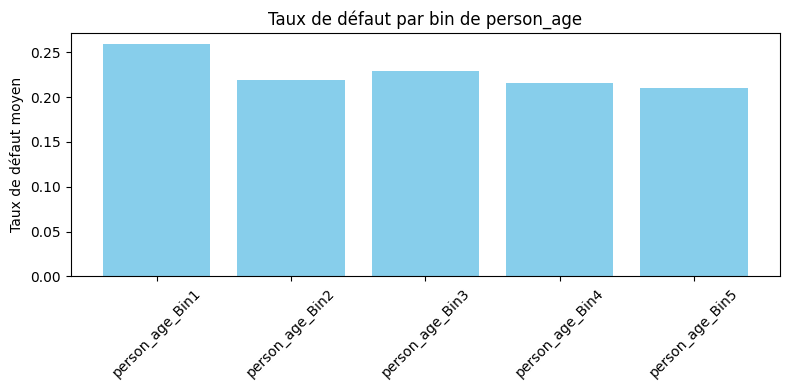

    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      6938     0.218939
2  person_age_Bin3      2769     0.228964
3  person_age_Bin4      7405     0.215935
4  person_age_Bin5      8010     0.210112


In [ ]:
print(check_binning_quality(df_credit_discretisation_v1,"person_age",target = "loan_status"))

In [ ]:
woe_df, iv_value = compute_woe_iv(df_credit_discretisation_v1, "person_age_bin", "loan_status")
print(woe_df)
print(f"\nIV total pour person_income : {iv_value:.4f}")


    person_age_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_age_Bin1   4609  1193  3416   0.147860  0.179994 -0.196660   
1  person_age_Bin2   6938  1519  5419   0.234558  0.229179  0.023200   
2  person_age_Bin3   2769   634  2135   0.092412  0.095655 -0.034486   
3  person_age_Bin4   7405  1599  5806   0.251309  0.241249  0.040854   
4  person_age_Bin5   8010  1683  6327   0.273861  0.253923  0.075589   

   IV_partial  
0    0.006320  
1    0.000125  
2    0.000112  
3    0.000411  
4    0.001507  

IV total pour person_income : 0.0085


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [ ]:
df_credit_discretisation_v1.columns

Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'person_age_bin'],
      dtype='object')

**Variable : person_income**

c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]



=== Vérification de la discrétisation : person_income ===
    person_income_bin  effectif  taux_defaut
0  person_income_Bin1      3081     0.456994
1  person_income_Bin2      3087     0.402008
2  person_income_Bin3      8823     0.225660
3  person_income_Bin4      8986     0.161919
4  person_income_Bin5      5754     0.092631

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


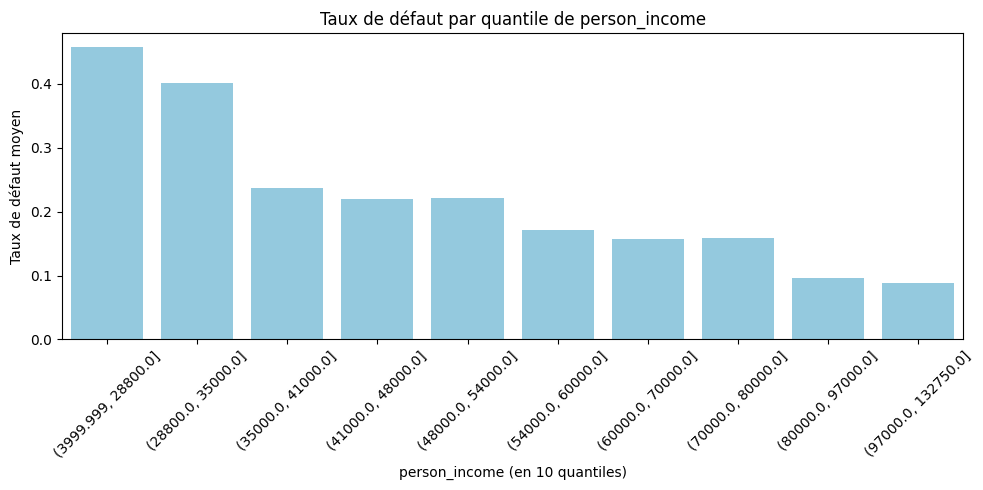

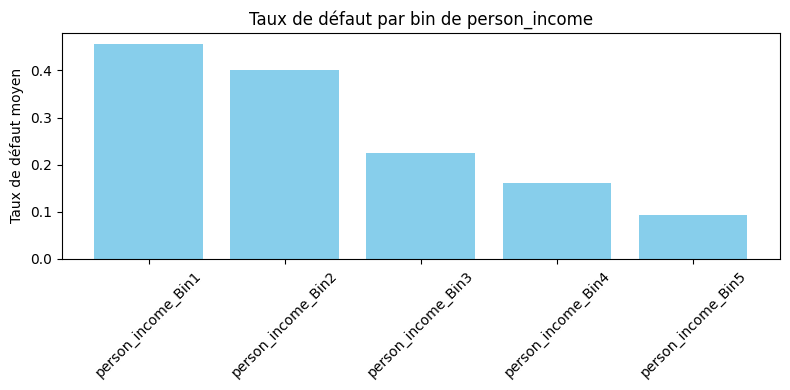

    person_income_bin  effectif  taux_defaut
0  person_income_Bin1      3081     0.456994
1  person_income_Bin2      3087     0.402008
2  person_income_Bin3      8823     0.225660
3  person_income_Bin4      8986     0.161919
4  person_income_Bin5      5754     0.092631
    person_income_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_income_Bin1   3081  1408  1673   0.072415  0.212432 -1.076211   
1  person_income_Bin2   3087  1241  1846   0.079903  0.187236 -0.851556   
2  person_income_Bin3   8823  1991  6832   0.295719  0.300392 -0.015679   
3  person_income_Bin4   8986  1455  7531   0.325975  0.219523  0.395363   
4  person_income_Bin5   5754   533  5221   0.225988  0.080416  1.033263   

   IV_partial  
0    0.150688  
1    0.091400  
2    0.000073  
3    0.042087  
4    0.150414  

IV total pour person_income : 0.4347


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [ ]:
plot_bad_rate_by_quantile(df = df_credit_discretisation,
                          var = "person_income",
                          q = 10)


counts = prepare_chimerge(df_credit_discretisation, "person_income", q=10)
intervals = apply_chimerge(counts, max_bins=5)
intervals

df_credit_discretisation_v2 = apply_binning(df_credit_discretisation,"person_income",intervals)

print(check_binning_quality(df_credit_discretisation_v2,"person_income",target = "loan_status"))

woe_df, iv_value = compute_woe_iv(df_credit_discretisation_v1, "person_income_bin", "loan_status")
print(woe_df)
print(f"\nIV total pour person_income : {iv_value:.4f}")


In [ ]:
df_credit_discretisation_v2.head()

,Unnamed: 0,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin,person_income_bin
0,1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,person_age_Bin1,person_income_Bin1
1,2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,person_age_Bin3,person_income_Bin1
2,3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,person_age_Bin2,person_income_Bin4
3,4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,person_age_Bin2,person_income_Bin4
4,5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,person_age_Bin1,person_income_Bin1


**Toutes les variables :**

c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]



=== Discrétisation de person_age ===

Intervalles finaux issus du ChiMerge :
      min   max  good   bad  bad_rate
0  19.999  22.0  3416  1193  0.258841
1  22.000  24.0  5419  1519  0.218939
2  24.000  25.0  2135   634  0.228964
3  25.000  29.0  5806  1599  0.215935
4  29.000  70.0  6327  1683  0.210112

✅ Variable discrétisée ajoutée : person_age_bin

=== Vérification de la discrétisation : person_age ===
    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      6938     0.218939
2  person_age_Bin3      2769     0.228964
3  person_age_Bin4      7405     0.215935
4  person_age_Bin5      8010     0.210112

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


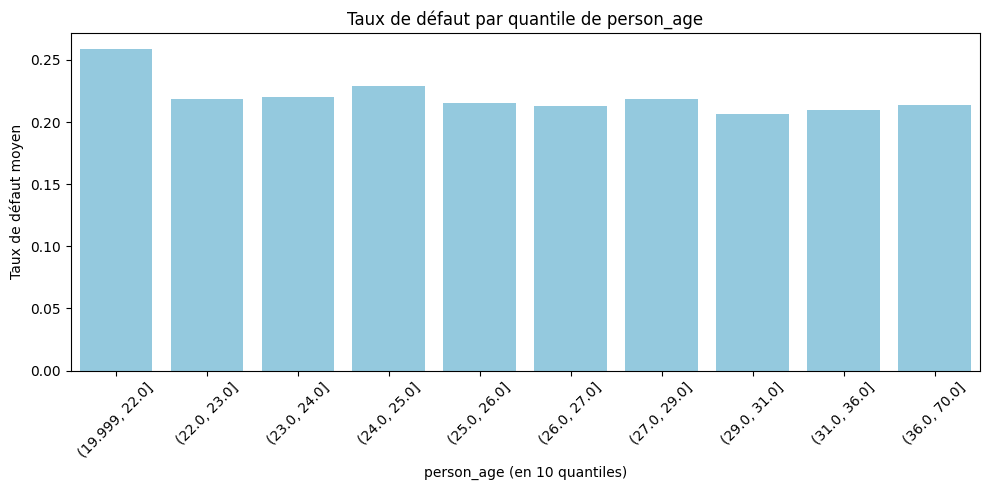

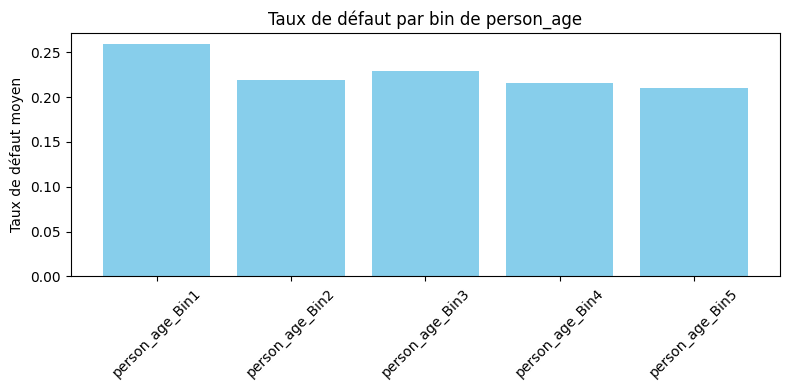

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]



Vérification de la qualité du binning :
    person_age_bin  effectif  taux_defaut
0  person_age_Bin1      4609     0.258841
1  person_age_Bin2      6938     0.218939
2  person_age_Bin3      2769     0.228964
3  person_age_Bin4      7405     0.215935
4  person_age_Bin5      8010     0.210112

=== Résumé WOE/IV pour person_age ===
    person_age_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_age_Bin1   4609  1193  3416   0.147860  0.179994 -0.196660   
1  person_age_Bin2   6938  1519  5419   0.234558  0.229179  0.023200   
2  person_age_Bin3   2769   634  2135   0.092412  0.095655 -0.034486   
3  person_age_Bin4   7405  1599  5806   0.251309  0.241249  0.040854   
4  person_age_Bin5   8010  1683  6327   0.273861  0.253923  0.075589   

   IV_partial  
0    0.006320  
1    0.000125  
2    0.000112  
3    0.000411  
4    0.001507  

IV total pour person_age : 0.0085

=== Discrétisation de person_income ===

Intervalles finaux issus du ChiMerge :
         min       max 

c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


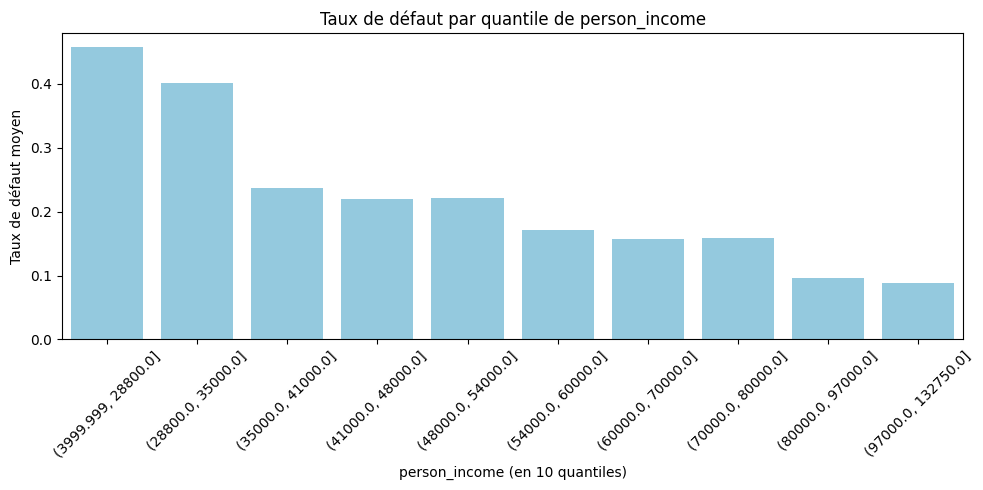

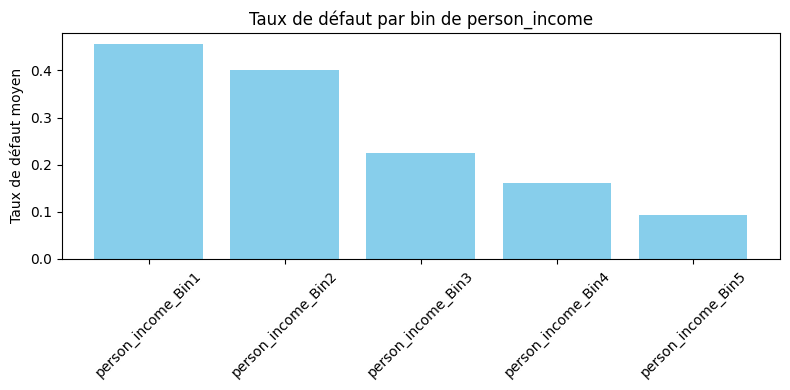


Vérification de la qualité du binning :
    person_income_bin  effectif  taux_defaut
0  person_income_Bin1      3081     0.456994
1  person_income_Bin2      3087     0.402008
2  person_income_Bin3      8823     0.225660
3  person_income_Bin4      8986     0.161919
4  person_income_Bin5      5754     0.092631

=== Résumé WOE/IV pour person_income ===
    person_income_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_income_Bin1   3081  1408  1673   0.072415  0.212432 -1.076211   
1  person_income_Bin2   3087  1241  1846   0.079903  0.187236 -0.851556   
2  person_income_Bin3   8823  1991  6832   0.295719  0.300392 -0.015679   
3  person_income_Bin4   8986  1455  7531   0.325975  0.219523  0.395363   
4  person_income_Bin5   5754   533  5221   0.225988  0.080416  1.033263   

   IV_partial  
0    0.150688  
1    0.091400  
2    0.000073  
3    0.042087  
4    0.150414  

IV total pour person_income : 0.4347

=== Discrétisation de person_emp_length ===


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]



Intervalles finaux issus du ChiMerge :
      min   max  good   bad  bad_rate
0  -0.001   1.0  4765  1914  0.286570
1   1.000   2.0  2682   965  0.264601
2   2.000   4.0  4718  1274  0.212617
3   4.000  10.0  8826  2038  0.187592
4  10.000  38.0  2112   437  0.171440

✅ Variable discrétisée ajoutée : person_emp_length_bin

=== Vérification de la discrétisation : person_emp_length ===
    person_emp_length_bin  effectif  taux_defaut
0  person_emp_length_Bin1      6679     0.286570
1  person_emp_length_Bin2      3647     0.264601
2  person_emp_length_Bin3      5992     0.212617
3  person_emp_length_Bin4     10864     0.187592
4  person_emp_length_Bin5      2549     0.171440

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


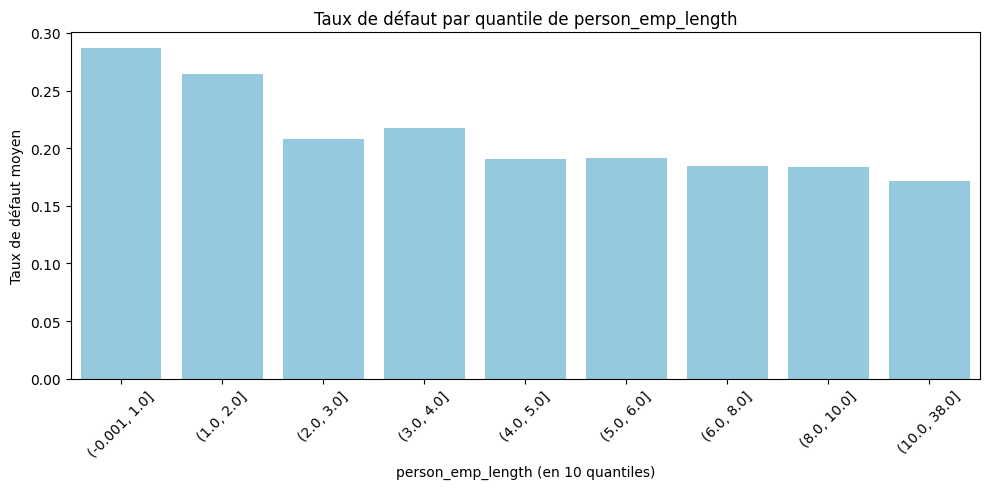

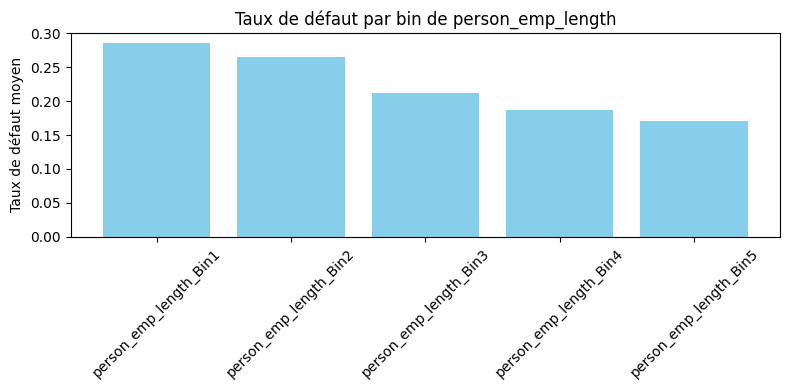

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167:


Vérification de la qualité du binning :
    person_emp_length_bin  effectif  taux_defaut
0  person_emp_length_Bin1      6679     0.286570
1  person_emp_length_Bin2      3647     0.264601
2  person_emp_length_Bin3      5992     0.212617
3  person_emp_length_Bin4     10864     0.187592
4  person_emp_length_Bin5      2549     0.171440

=== Résumé WOE/IV pour person_emp_length ===
    person_emp_length_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  person_emp_length_Bin1   6679  1914  4765   0.206250  0.288775 -0.336557   
1  person_emp_length_Bin2   3647   965  2682   0.116089  0.145594 -0.226469   
2  person_emp_length_Bin3   5992  1274  4718   0.204216  0.192215  0.060564   
3  person_emp_length_Bin4  10864  2038  8826   0.382028  0.307483  0.217074   
4  person_emp_length_Bin5   2549   437  2112   0.091417  0.065932  0.326798   

   IV_partial  
0    0.027774  
1    0.006682  
2    0.000727  
3    0.016182  
4    0.008328  

IV total pour person_emp_length : 0.0597

=== D

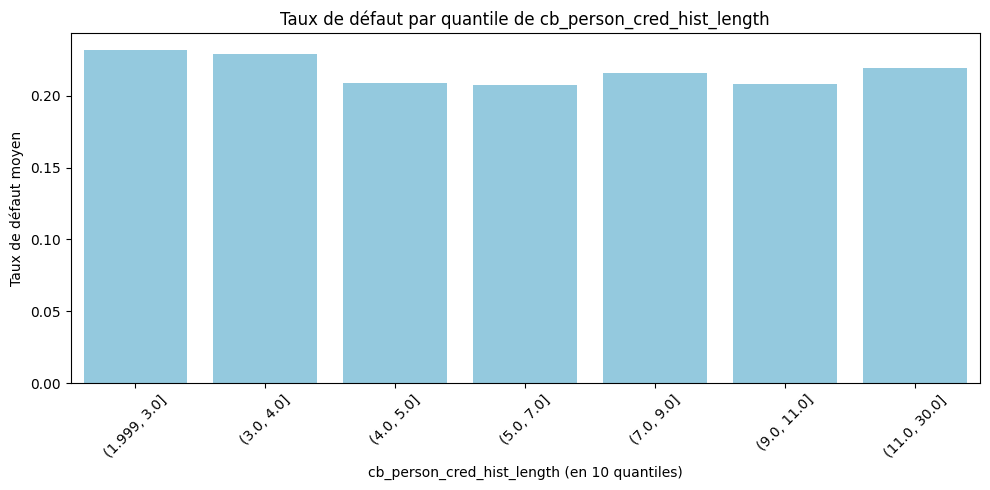

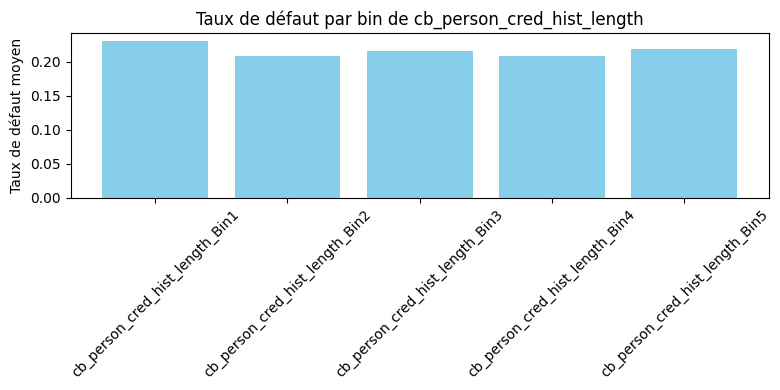


Vérification de la qualité du binning :
    cb_person_cred_hist_length_bin  effectif  taux_defaut
0  cb_person_cred_hist_length_Bin1     16575     0.231252
1  cb_person_cred_hist_length_Bin2      5073     0.208161
2  cb_person_cred_hist_length_Bin3      3395     0.215906
3  cb_person_cred_hist_length_Bin4      2051     0.208191
4  cb_person_cred_hist_length_Bin5      2637     0.219568

=== Résumé WOE/IV pour cb_person_cred_hist_length ===
    cb_person_cred_hist_length_bin  total   bad   good  dist_good  dist_bad  \
0  cb_person_cred_hist_length_Bin1  16575  3833  12742   0.551530  0.578304   
1  cb_person_cred_hist_length_Bin2   5073  1056   4017   0.173874  0.159324   
2  cb_person_cred_hist_length_Bin3   3395   733   2662   0.115223  0.110591   
3  cb_person_cred_hist_length_Bin4   2051   427   1624   0.070294  0.064424   
4  cb_person_cred_hist_length_Bin5   2637   579   2058   0.089079  0.087357   

        WOE  IV_partial  
0 -0.047404    0.001269  
1  0.087388    0.001271  
2  

c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [ ]:
# Liste des variables numériques à discrétiser
numeric_vars = [
    "person_age",
    "person_income",
    "person_emp_length",
    # "loan_amnt",
    # "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Copie de travail
df_credit_discret = df_credit.copy()

# Boucle principale
for var in numeric_vars:
    print("\n" + "=" * 80)
    print(f"=== Discrétisation de {var} ===")
    print("=" * 80)
    
    try:
        # 1️⃣ Plot du taux de défaut initial
        plot_bad_rate_by_quantile(df_credit_discret, var, q=10)
        
        # 2️⃣ Application du ChiMerge avec contrôle du nombre de bins
        counts = prepare_chimerge_auto(df_credit_discret, var, q=10)

        n_init_bins = counts.shape[0]
        desired_bins = min(5, n_init_bins)

        intervals = apply_chimerge(counts, max_bins=desired_bins)

        if len(intervals) > 5:
            print(f"⚠️ {var}: {len(intervals)} bins détectés — réduction à 5 par fusion finale.")
            intervals = intervals.iloc[:5].copy()
            intervals.loc[4, "max"] = counts["max"].max()

        print("\nIntervalles finaux issus du ChiMerge :")
        print(intervals)

        # 3️⃣ Application du binning directement dans df_credit_discret
        df_credit_discret = apply_binning(df_credit_discret, var, intervals)
        print(f"\n✅ Variable discrétisée ajoutée : {var}_bin")
        
        # 4️⃣ Vérification de la qualité du binning
        quality_check = check_binning_quality(df_credit_discret, var, target="loan_status")
        print("\nVérification de la qualité du binning :")
        print(quality_check)
        
        # 5️⃣ Calcul du WOE & IV
        var_bin_name = f"{var}_bin"
        woe_df, iv_value = compute_woe_iv(df_credit_discret, var_bin_name, "loan_status")
        
        print(f"\n=== Résumé WOE/IV pour {var} ===")
        print(woe_df)
        print(f"\nIV total pour {var} : {iv_value:.4f}")

    except Exception as e:
        print(f"⚠️ Erreur lors du traitement de {var} : {e}")

print("\n✅ Discrétisation terminée pour toutes les variables numériques.")


In [ ]:
df_credit_discret

,Unnamed: 0,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin,person_income_bin,person_emp_length_bin,cb_person_cred_hist_length_bin
0,1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin4,cb_person_cred_hist_length_Bin1
1,2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,person_age_Bin3,person_income_Bin1,person_emp_length_Bin1,cb_person_cred_hist_length_Bin1
2,3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,person_age_Bin2,person_income_Bin4,person_emp_length_Bin3,cb_person_cred_hist_length_Bin1
3,4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,person_age_Bin2,person_income_Bin4,person_emp_length_Bin4,cb_person_cred_hist_length_Bin1
4,5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin2,cb_person_cred_hist_length_Bin1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29726,32575,52,64500,RENT,0.0,EDUCATION,B,5000,11.26,0,0.08,N,20,person_age_Bin5,person_income_Bin4,person_emp_length_Bin1,cb_person_cred_hist_length_Bin5
29727,32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,person_age_Bin5,person_income_Bin3,person_emp_length_Bin1,cb_person_cred_hist_length_Bin5
29728,32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,person_age_Bin5,person_income_Bin5,person_emp_length_Bin3,cb_person_cred_hist_length_Bin5
29729,32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,person_age_Bin5,person_income_Bin4,person_emp_length_Bin3,cb_person_cred_hist_length_Bin5


In [ ]:
# 🔍 Afficher les effectifs des variables discrétisées (toutes celles finissant par "_bin")
bin_vars = [col for col in df_credit_discret.columns if col.endswith("_bin")]


for var in bin_vars:
    print(f"\n📊 {var} :")
    print(df_credit_discret[var].value_counts(dropna=False).sort_index())



📊 person_age_bin :
person_age_bin
person_age_Bin1    4609
person_age_Bin2    6938
person_age_Bin3    2769
person_age_Bin4    7405
person_age_Bin5    8010
Name: count, dtype: int64

📊 person_income_bin :
person_income_bin
person_income_Bin1    3081
person_income_Bin2    3087
person_income_Bin3    8823
person_income_Bin4    8986
person_income_Bin5    5754
Name: count, dtype: int64

📊 person_emp_length_bin :
person_emp_length_bin
person_emp_length_Bin1     6679
person_emp_length_Bin2     3647
person_emp_length_Bin3     5992
person_emp_length_Bin4    10864
person_emp_length_Bin5     2549
Name: count, dtype: int64

📊 cb_person_cred_hist_length_bin :
cb_person_cred_hist_length_bin
cb_person_cred_hist_length_Bin1    16575
cb_person_cred_hist_length_Bin2     5073
cb_person_cred_hist_length_Bin3     3395
cb_person_cred_hist_length_Bin4     2051
cb_person_cred_hist_length_Bin5     2637
Name: count, dtype: int64



=== Vérification de la discrétisation : loan_amnt ===
    loan_amnt_bin  effectif  taux_defaut
0  loan_amnt_Bin1      8963     0.200045
1  loan_amnt_Bin2      6711     0.168976
2  loan_amnt_Bin3      8346     0.210400
3  loan_amnt_Bin4      2991     0.291541
4  loan_amnt_Bin5      2720     0.394485

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


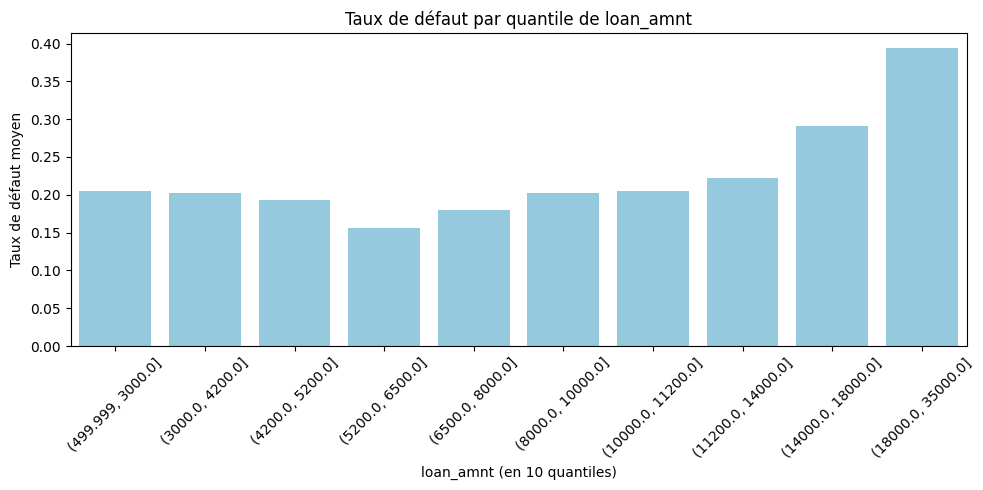

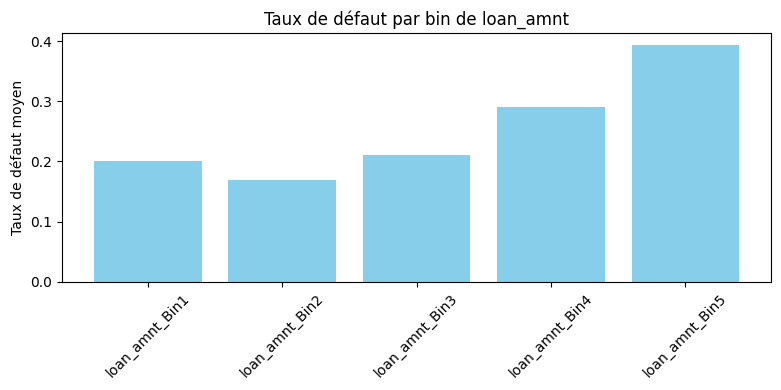

    loan_amnt_bin  effectif  taux_defaut
0  loan_amnt_Bin1      8963     0.200045
1  loan_amnt_Bin2      6711     0.168976
2  loan_amnt_Bin3      8346     0.210400
3  loan_amnt_Bin4      2991     0.291541
4  loan_amnt_Bin5      2720     0.394485
    loan_amnt_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  loan_amnt_Bin1   8963  1793  7170   0.310349  0.270519  0.137356   
1  loan_amnt_Bin2   6711  1134  5577   0.241397  0.171092  0.344240   
2  loan_amnt_Bin3   8346  1756  6590   0.285244  0.264937  0.073855   
3  loan_amnt_Bin4   2991   872  2119   0.091720  0.131563 -0.360749   
4  loan_amnt_Bin5   2720  1073  1647   0.071289  0.161889 -0.820162   

   IV_partial  
0    0.005471  
1    0.024202  
2    0.001500  
3    0.014373  
4    0.074306  

IV total pour loan_amnt : 0.1199


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [ ]:
def apply_chimerge_2(counts: pd.DataFrame, max_bins: int = 5) -> pd.DataFrame:
    """
    Version robuste du ChiMerge : 
    - Ajoute automatiquement les colonnes 'min' et 'max' si absentes
    - Garantit un nombre maximum de bins (<= max_bins)
    """

    intervals = counts.copy().reset_index(drop=True)

    # --- Ajout automatique des bornes min / max ---
    if "min" not in intervals.columns or "max" not in intervals.columns:
        if isinstance(intervals.iloc[0, 0], pd.Interval):
            intervals["min"] = [x.left for x in intervals.iloc[:, 0]]
            intervals["max"] = [x.right for x in intervals.iloc[:, 0]]
        else:
            raise ValueError("Impossible de déduire les bornes : la première colonne n’est pas un intervalle.")

    # --- Boucle principale du ChiMerge ---
    while len(intervals) > max_bins:
        chi_values = []
        for i in range(len(intervals) - 1):
            c1 = intervals.iloc[i]
            c2 = intervals.iloc[i + 1]

            # Table de contingence 2x2
            obs = np.array([
                [c1["bad"], c1["good"]],
                [c2["bad"], c2["good"]]
            ])

            chi_val = chi2_contingency(obs, correction=False)[0]
            chi_values.append(chi_val)

        # Trouver les 2 bins les plus similaires
        min_index = np.argmin(chi_values)

        # Fusionner les 2 bins
        intervals.loc[min_index, "max"] = intervals.loc[min_index + 1, "max"]
        intervals.loc[min_index, "bad"] += intervals.loc[min_index + 1, "bad"]
        intervals.loc[min_index, "good"] += intervals.loc[min_index + 1, "good"]
        intervals.loc[min_index, "total"] += intervals.loc[min_index + 1, "total"]

        # Supprimer le bin fusionné
        intervals = intervals.drop(index=min_index + 1).reset_index(drop=True)

    # Sélection finale des colonnes utiles
    return intervals[["min", "max", "good", "bad"]]



plot_bad_rate_by_quantile(df = df_credit_discret,
                          var = "loan_amnt",
                          q = 10)


counts = prepare_chimerge(df_credit_discret, "loan_amnt", q=10)
intervals = apply_chimerge_2(counts, max_bins=5)
intervals

df_credit_discret_v2 = apply_binning(df_credit_discret,"loan_amnt",intervals)

print(check_binning_quality(df_credit_discret_v2,"loan_amnt",target = "loan_status"))

woe_df, iv_value = compute_woe_iv(df_credit_discret_v2, "loan_amnt_bin", "loan_status")
print(woe_df)
print(f"\nIV total pour loan_amnt : {iv_value:.4f}")



=== Vérification de la discrétisation : loan_percent_income ===
    loan_percent_income_bin  effectif  taux_defaut
0  loan_percent_income_Bin1      3911     0.108412
1  loan_percent_income_Bin2     11205     0.129228
2  loan_percent_income_Bin3      9076     0.188189
3  loan_percent_income_Bin4      2573     0.364555
4  loan_percent_income_Bin5      2966     0.711396

→ Vérifie que le taux de défaut évolue de manière cohérente (monotone).


c:\Mosef\scoring\projet\src\discretization.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col_bin)[target]
c:\Mosef\scoring\projet\src\discretization.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


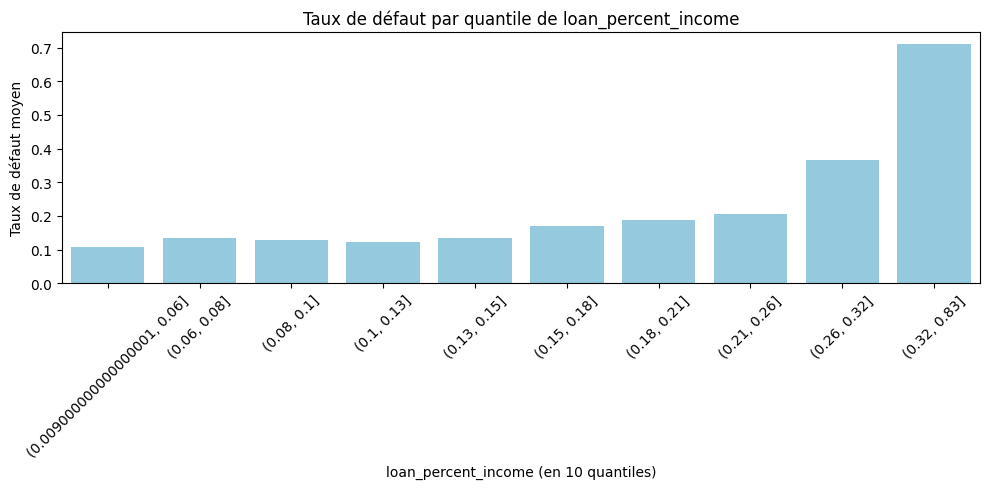

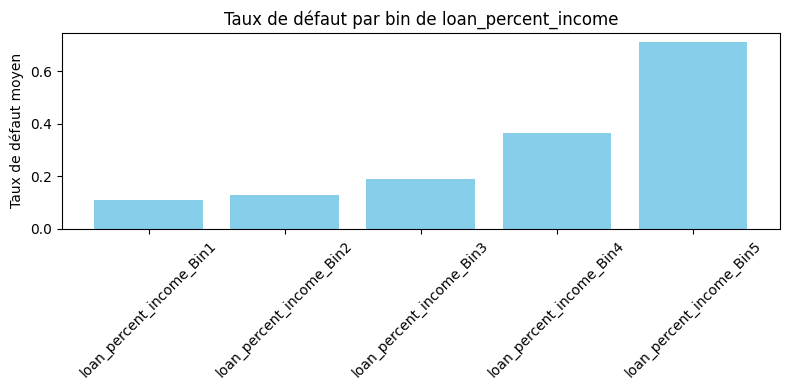

    loan_percent_income_bin  effectif  taux_defaut
0  loan_percent_income_Bin1      3911     0.108412
1  loan_percent_income_Bin2     11205     0.129228
2  loan_percent_income_Bin3      9076     0.188189
3  loan_percent_income_Bin4      2573     0.364555
4  loan_percent_income_Bin5      2966     0.711396
    loan_percent_income_bin  total   bad  good  dist_good  dist_bad       WOE  \
0  loan_percent_income_Bin1   3911   424  3487   0.150933  0.063971  0.858404   
1  loan_percent_income_Bin2  11205  1448  9757   0.422326  0.218467  0.659142   
2  loan_percent_income_Bin3   9076  1708  7368   0.318920  0.257695  0.213164   
3  loan_percent_income_Bin4   2573   938  1635   0.070770  0.141521 -0.693011   
4  loan_percent_income_Bin5   2966  2110   856   0.037051  0.318346 -2.150832   

   IV_partial  
0    0.074648  
1    0.134372  
2    0.013051  
3    0.049031  
4    0.605018  

IV total pour loan_percent_income : 0.8761


c:\Mosef\scoring\projet\src\discretization.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var_bin)[target]


In [ ]:

plot_bad_rate_by_quantile(df = df_credit_discret_v2,
                          var = "loan_percent_income",
                          q = 10)


counts = prepare_chimerge(df_credit_discret, "loan_percent_income", q=10)
intervals = apply_chimerge_2(counts, max_bins=5)
intervals

df_credit_discret_v3 = apply_binning(df_credit_discret_v2,"loan_percent_income",intervals)

print(check_binning_quality(df_credit_discret_v3,"loan_percent_income",target = "loan_status"))

woe_df, iv_value = compute_woe_iv(df_credit_discret_v3, "loan_percent_income_bin", "loan_status")
print(woe_df)
print(f"\nIV total pour loan_percent_income : {iv_value:.4f}")


In [ ]:
# 🔍 Afficher les effectifs des variables discrétisées (toutes celles finissant par "_bin")
bin_vars = [col for col in df_credit_discret_v3.columns if col.endswith("_bin")]


for var in bin_vars:
    print(f"\n📊 {var} :")
    print(df_credit_discret[var].value_counts(dropna=False).sort_index())



📊 person_age_bin :
person_age_bin
person_age_Bin1    4609
person_age_Bin2    6938
person_age_Bin3    2769
person_age_Bin4    7405
person_age_Bin5    8010
Name: count, dtype: int64

📊 person_income_bin :
person_income_bin
person_income_Bin1    3081
person_income_Bin2    3087
person_income_Bin3    8823
person_income_Bin4    8986
person_income_Bin5    5754
Name: count, dtype: int64

📊 person_emp_length_bin :
person_emp_length_bin
person_emp_length_Bin1     6679
person_emp_length_Bin2     3647
person_emp_length_Bin3     5992
person_emp_length_Bin4    10864
person_emp_length_Bin5     2549
Name: count, dtype: int64

📊 cb_person_cred_hist_length_bin :
cb_person_cred_hist_length_bin
cb_person_cred_hist_length_Bin1    16575
cb_person_cred_hist_length_Bin2     5073
cb_person_cred_hist_length_Bin3     3395
cb_person_cred_hist_length_Bin4     2051
cb_person_cred_hist_length_Bin5     2637
Name: count, dtype: int64

📊 loan_amnt_bin :
loan_amnt_bin
loan_amnt_Bin1    8963
loan_amnt_Bin2    6711
loan_

**Pareil mais pour les 2 variables categorielles qui ont + que 5 categories :**

In [ ]:
regroupement_loan_intent, df_credit_discret_v4 = chimerge_categorical(
    df=df_credit_discret_v3,
    var="loan_intent",
    target="loan_status",
    max_bins=5,      # max 5 groupes
    min_pct=0.05,    # au moins 5 % des observations par groupe
    verbose=True
)



✅ Regroupement final pour loan_intent :
   effectif  pct_total  taux_defaut
0      4746   0.159631     0.290139
1      5934   0.199590     0.174756
2      8830   0.296996     0.271234
3      5035   0.169352     0.202781
4      5186   0.174431     0.153876


In [ ]:
df_credit_discret_v4.head()

,Unnamed: 0,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin,person_income_bin,person_emp_length_bin,cb_person_cred_hist_length_bin,loan_amnt_bin,loan_percent_income_bin,loan_intent_bin
0,1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin4,cb_person_cred_hist_length_Bin1,loan_amnt_Bin1,loan_percent_income_Bin2,EDUCATION
1,2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,person_age_Bin3,person_income_Bin1,person_emp_length_Bin1,cb_person_cred_hist_length_Bin1,loan_amnt_Bin2,loan_percent_income_Bin5,HOMEIMPROVEMENT_MEDICAL
2,3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,person_age_Bin2,person_income_Bin4,person_emp_length_Bin3,cb_person_cred_hist_length_Bin1,loan_amnt_Bin5,loan_percent_income_Bin5,HOMEIMPROVEMENT_MEDICAL
3,4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,person_age_Bin2,person_income_Bin4,person_emp_length_Bin4,cb_person_cred_hist_length_Bin1,loan_amnt_Bin5,loan_percent_income_Bin5,HOMEIMPROVEMENT_MEDICAL
4,5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,person_age_Bin1,person_income_Bin1,person_emp_length_Bin2,cb_person_cred_hist_length_Bin1,loan_amnt_Bin1,loan_percent_income_Bin3,VENTURE


In [ ]:
df_credit_discret_v4.to_csv(path_or_buf="../data/output/df_discretise.csv",
                            sep = ",")